# Patent Hardware Classification – Data Engineering Pipeline

This notebook focuses on the data engineering process for building a structured dataset of patents related to hardware technologies. The raw patent data is stored in JSON format and contains information such as the application number, title, abstract, and claims.

The goal of this notebook is to extract relevant fields from multiple patent files, clean and preprocess the text data, and filter patents that are related to hardware technologies. The resulting dataset will be used for further analysis and machine learning tasks in later stages of the project.

## Problem Statement

Patent databases contain thousands of documents covering multiple domains such as electronics, biotechnology, pharmaceuticals, and mechanical engineering. However, for many research and analysis tasks, it is necessary to focus only on patents related to specific domains.

The objective of this project is to identify and extract patents related to hardware technologies by processing raw patent documents. This involves collecting patent data from JSON files, extracting relevant textual fields, cleaning the data, and filtering patents using domain-specific keywords.

## Project Workflow

The data engineering pipeline in this project follows several important steps:

1. Import required libraries for data processing.
2. Load raw patent data from JSON files.
3. Extract important attributes such as title, abstract, and claims.
4. Combine textual information into a structured dataset.
5. Perform data cleaning and preprocessing.
6. Apply keyword-based filtering to identify hardware-related patents.
7. Generate a final dataset suitable for machine learning analysis.

## Importing Required Libraries

In this step, the required Python libraries for data processing and analysis are imported. Libraries such as pandas, json, os, and matplotlib are used for reading data files, manipulating datasets, and performing exploratory analysis.


In [ ]:
import pandas as pd
import numpy as np
import json
import os
import re
import string

from tqdm import tqdm

from sklearn.utils import resample

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## Data Collection

The dataset consists of multiple JSON patent files stored in a directory. Each file contains information such as the patent title, abstract, and claims.

In this step, the program iterates through all JSON files in the directory and extracts the relevant information needed for analysis.

## Data Collection

The dataset used in this project consists of multiple JSON files containing patent information. Each file includes important attributes such as:

- Application Number
- Title
- Abstract
- Claims

These files are stored in a directory and are processed sequentially to extract relevant information for the dataset.

In [26]:
folder = r"C:\Users\jewel\Downloads\hupd_2018\2018"

data = []

files = os.listdir(folder)

for file in tqdm(files):

    if file.endswith(".json"):

        path = os.path.join(folder, file)

        with open(path, "r", encoding="utf-8") as f:

            patent = json.load(f)

            application_number = patent.get("application_number")
            title = patent.get("title", "")
            abstract = patent.get("abstract", "")
            claims = patent.get("claims", "")

            text = title + " " + abstract + " " + claims

            data.append({
                "application_number": application_number,
                "title": title,
                "abstract": abstract,
                "claims": claims,
                "text": text
            })

df = pd.DataFrame(data)

df.to_csv("patents_2018.csv", index=False)

print("Dataset created")
print(df.shape)

100%|██████████| 31968/31968 [04:57<00:00, 107.44it/s]


Dataset created
(31968, 5)


## Loading Patent Data

In this step, the program reads all JSON files from the specified directory and extracts relevant information from each file.

The extracted fields include the application number, title, abstract, and claims of each patent. These fields represent the main textual description of the patent and are essential for identifying hardware-related technologies.

In [27]:
df.head()

,application_number,title,abstract,claims,text
0,13817165,Intelligent Drug and/or Fluid Delivery System ...,"A pharmacodynamic (PD), pharmacokinetic (PK), ...",1. A medication or fluid delivery and control ...,Intelligent Drug and/or Fluid Delivery System ...
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,ANTISTATIC DEVICE AND ASSOCIATED OPERATING MET...
2,14112715,APPARATUS AND METHODS FOR ASSESSING THE EFFECT...,A method of assessing the effect of viewing va...,1. A method of assessing the effect of viewing...,APPARATUS AND METHODS FOR ASSESSING THE EFFECT...
3,14764986,"BLACK MATRIX, METHOD FOR MANUFACTURING THE SAM...","The disclosure provides a black matrix, a meth...","1. A black matrix, manufactured by the steps o...","BLACK MATRIX, METHOD FOR MANUFACTURING THE SAM..."
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",A LIGHTING CONTROL SYSTEM The invention relate...


## Data Preprocessing

Raw textual data often contains inconsistencies such as punctuation, uppercase letters, and unnecessary characters. Therefore, preprocessing is required to standardize the dataset.

The preprocessing process includes:

- Converting text to lowercase
- Removing punctuation and special characters
- Eliminating unnecessary whitespace
- Preparing the text data for further analysis

In [28]:
df["text"] = df["text"].str.lower()

df["text"] = df["text"].apply(lambda x: re.sub(r"[^\w\s]", " ", x))

df = df.drop_duplicates(subset="text")

print("After cleaning:", df.shape)


After cleaning: (31959, 5)


## Hardware Keyword Identification

To identify hardware-related patents, a list of hardware-specific keywords is defined. These keywords represent components and concepts commonly used in electronic and embedded systems.

Examples of hardware-related keywords include:

- processor
- microcontroller
- circuit
- transistor
- sensor
- signal
- memory
- voltage

In [29]:
import re

hardware_keywords = [
"processor","microprocessor","semiconductor","circuit","transistor",
"sensor","microcontroller","hardware","voltage","current",
"signal","power","controller","chip","integrated circuit",
"fpga","logic","pcb","memory","embedded","analog",
"digital","clock","bus","register","gpio","adc","dac"
]

non_hardware_keywords = [
"antibody","antigen","pyridine","pyrazole","imidazole",
"culture","compound","acid","pharmaceutical","drug",
"protein","peptide","dna","rna","gene","biological"
]


def is_hardware(text):

    text = text.lower()

    # Remove biotech patents
    if any(re.search(r'\b'+w+r'\b', text) for w in non_hardware_keywords):
        return False

    # Count hardware terms
    count = sum(bool(re.search(r'\b'+w+r'\b', text)) for w in hardware_keywords)

    return count >= 2


df = df[df["text"].apply(is_hardware)]

print("After hardware filtering:", df.shape)

After hardware filtering: (9661, 5)


In [30]:
df.head()

,application_number,title,abstract,claims,text
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,antistatic device and associated operating met...
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",a lighting control system the invention relate...
11,14897676,TOUCH DISPLAY PANEL AND CONTROL CIRCUIT THEREOF,Provided is a touch control display penal and ...,1. A touch control circuit of a touch display ...,touch display panel and control circuit thereo...
12,14897677,ARRAY SUBSTRATE AND METHOD FOR MANUFACTURING T...,Disclosed are an array substrate and a method ...,1. A method for manufacturing an array substra...,array substrate and method for manufacturing t...
13,14897695,LIQUID CRYSTAL DISPLAY DEVICE IN PERPENDICULAR...,A liquid crystal display device in vertical al...,1. A liquid crystal display device in vertical...,liquid crystal display device in perpendicular...


## Removing Non-Hardware Patents

Patent datasets often contain records related to biology, pharmaceuticals, and other unrelated fields. To ensure the dataset focuses on hardware technologies, a filtering mechanism is applied.

Patents containing biological or pharmaceutical keywords such as:

- protein
- antibody
- gene
- pharmaceutical

are excluded from the dataset.

In [31]:
# Stopwords list
stopwords = set([
'a','an','the','and','or','but','if','while','with','to','of','at','by','for','from',
'up','about','into','over','after','is','are','was','were','be','been','being','have',
'has','had','do','does','did','this','that','these','those','in','on','it','its','as',
'such','their','there','than','then','so','because','can','will','just','should'
])

# Patent boilerplate stopwords (safe to remove)
patent_stopwords = [
"claim","claims","wherein","said","according",
"comprising","comprises","plurality","least",
"first","second","one","configured","includes",
"including","associated","based","using","provided"
]

stopwords.update(patent_stopwords)


def remove_stopwords(text):

    words = text.split()

    words = [w for w in words if w not in stopwords]

    return " ".join(words)


# Apply preprocessing
df["clean_text"] = df["text"].apply(remove_stopwords)

# Remove empty rows
df = df.dropna(subset=["clean_text"])

# Remove very short rows
df = df[df["clean_text"].str.len() > 20]

print("After preprocessing:", df.shape)

After preprocessing: (9661, 6)


## Hardware Patent Filtering

A filtering function is applied to identify patents that contain relevant hardware keywords.

The filtering logic works as follows:

- If a patent contains biological keywords, it is removed.
- If a patent contains multiple hardware-related keywords, it is classified as a hardware patent.

This ensures that only relevant hardware-related patents remain in the dataset.

In [32]:
df.head()

,application_number,title,abstract,claims,text,clean_text
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,antistatic device and associated operating met...,antistatic device operating method antistatic ...
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",a lighting control system the invention relate...,lighting control system invention relates fiel...
11,14897676,TOUCH DISPLAY PANEL AND CONTROL CIRCUIT THEREOF,Provided is a touch control display penal and ...,1. A touch control circuit of a touch display ...,touch display panel and control circuit thereo...,touch display panel control circuit thereof to...
12,14897677,ARRAY SUBSTRATE AND METHOD FOR MANUFACTURING T...,Disclosed are an array substrate and a method ...,1. A method for manufacturing an array substra...,array substrate and method for manufacturing t...,array substrate method manufacturing same disc...
13,14897695,LIQUID CRYSTAL DISPLAY DEVICE IN PERPENDICULAR...,A liquid crystal display device in vertical al...,1. A liquid crystal display device in vertical...,liquid crystal display device in perpendicular...,liquid crystal display device perpendicular al...


## Data Exploration and Visualization

After cleaning the patent text, exploratory analysis is performed to understand the characteristics of the dataset. This includes examining patent descriptions and identifying terms that indicate technological innovation.

A novelty scoring mechanism is introduced to measure how innovative a patent appears based on the presence of specific keywords related to breakthrough technologies.

In [33]:
def compute_novelty_score(text):

    text = text.lower()

    breakthrough = ["breakthrough","revolutionary","unprecedented","pioneer"]
    high = ["novel","inventive","unique","innovative","original"]
    moderate = ["new","improved","enhanced","advanced","optimized"]
    negative = ["conventional","prior art","standard","known"]

    score = 0

    for word in breakthrough:
        score += 5 * len(re.findall(r'\b'+word+r'\b', text))

    for word in high:
        score += 3 * len(re.findall(r'\b'+word+r'\b', text))

    for word in moderate:
        score += 1.5 * len(re.findall(r'\b'+word+r'\b', text))

    for word in negative:
        score -= 1 * len(re.findall(r'\b'+word+r'\b', text))

    words = text.split()

    if len(words) > 0:
        diversity = len(set(words)) / len(words)
        score += (len(words) / 100) * diversity

    return score


df["novelty_score"] = df["text"].apply(compute_novelty_score)

In [34]:
df.head()

,application_number,title,abstract,claims,text,clean_text,novelty_score
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,antistatic device and associated operating met...,antistatic device operating method antistatic ...,2.48
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",a lighting control system the invention relate...,lighting control system invention relates fiel...,1.65
11,14897676,TOUCH DISPLAY PANEL AND CONTROL CIRCUIT THEREOF,Provided is a touch control display penal and ...,1. A touch control circuit of a touch display ...,touch display panel and control circuit thereo...,touch display panel control circuit thereof to...,1.79
12,14897677,ARRAY SUBSTRATE AND METHOD FOR MANUFACTURING T...,Disclosed are an array substrate and a method ...,1. A method for manufacturing an array substra...,array substrate and method for manufacturing t...,array substrate method manufacturing same disc...,1.30
13,14897695,LIQUID CRYSTAL DISPLAY DEVICE IN PERPENDICULAR...,A liquid crystal display device in vertical al...,1. A liquid crystal display device in vertical...,liquid crystal display device in perpendicular...,liquid crystal display device perpendicular al...,1.51


## Final Dataset Preparation

Once the novelty score for each patent is computed, patents are categorized into different novelty tiers. These tiers represent different levels of innovation based on the computed scores.

The tier assignment function converts the novelty score into discrete categories, making it easier to analyze and visualize the distribution of patents across innovation levels.

In [35]:
def assign_tier(score):

    if score >= 15:
        return 3
    elif score >= 5:
        return 2
    elif score >= 1:
        return 1
    else:
        return 0


df["novelty tier"] = df["novelty_score"].apply(assign_tier)

print("Original distribution")
print(df["novelty tier"].value_counts())

Original distribution
novelty tier
1    8103
0     909
2     430
3     219
Name: count, dtype: int64


## Visualization of Novelty Distribution

To better understand the dataset, the distribution of novelty tiers is visualized using graphical plots. These plots illustrate how patents are distributed across different levels of innovation.

Visualization helps identify patterns in the data and provides insight into how many patents fall into each novelty category.

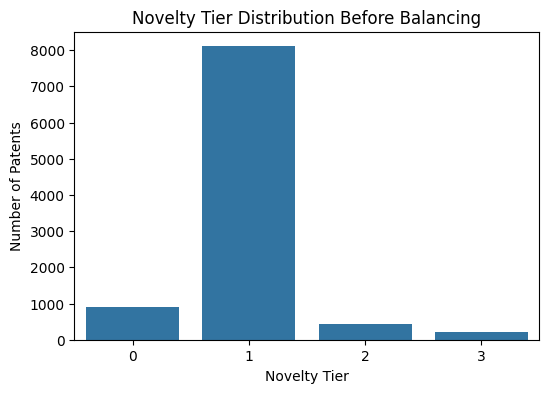

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["novelty tier"])

plt.title("Novelty Tier Distribution Before Balancing")
plt.xlabel("Novelty Tier")
plt.ylabel("Number of Patents")

plt.show()

In [47]:
from sklearn.utils import resample

target_size = 400

balanced_data = []

for tier in sorted(df["novelty tier"].unique()):

    tier_df = df[df["novelty tier"] == tier]

    # If class is smaller → oversample
    if len(tier_df) < target_size:

        balanced = resample(
            tier_df,
            replace=True,
            n_samples=target_size,
            random_state=42
        )

    # If class is larger → downsample
    else:

        balanced = resample(
            tier_df,
            replace=False,
            n_samples=target_size,
            random_state=42
        )

    balanced_data.append(balanced)


df_balanced = pd.concat(balanced_data)

# Shuffle dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced distribution")
print(df_balanced["novelty tier"].value_counts())

print("Dataset size:", df_balanced.shape)

Balanced distribution
novelty tier
1    400
0    400
2    400
3    400
Name: count, dtype: int64
Dataset size: (1600, 8)


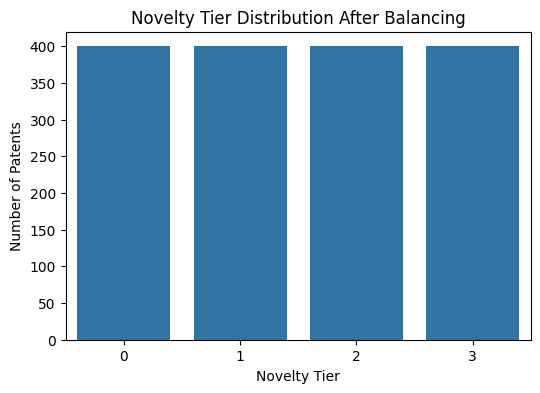

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(x=df_balanced["novelty tier"])

plt.title("Novelty Tier Distribution After Balancing")
plt.xlabel("Novelty Tier")
plt.ylabel("Number of Patents")

plt.show()

In [49]:
df.head()

,application_number,title,abstract,claims,text,clean_text,novelty_score,novelty tier
1,14111139,ANTISTATIC DEVICE AND ASSOCIATED OPERATING METHOD,An antistatic device for reducing electrostati...,1. Antistatic device for reducing electrostati...,antistatic device and associated operating met...,antistatic device operating method antistatic ...,2.48,1
4,14765061,A LIGHTING CONTROL SYSTEM,The invention relates to the field of smart se...,"1. A lighting control system, applied for adju...",a lighting control system the invention relate...,lighting control system invention relates fiel...,1.65,1
11,14897676,TOUCH DISPLAY PANEL AND CONTROL CIRCUIT THEREOF,Provided is a touch control display penal and ...,1. A touch control circuit of a touch display ...,touch display panel and control circuit thereo...,touch display panel control circuit thereof to...,1.79,1
12,14897677,ARRAY SUBSTRATE AND METHOD FOR MANUFACTURING T...,Disclosed are an array substrate and a method ...,1. A method for manufacturing an array substra...,array substrate and method for manufacturing t...,array substrate method manufacturing same disc...,1.30,1
13,14897695,LIQUID CRYSTAL DISPLAY DEVICE IN PERPENDICULAR...,A liquid crystal display device in vertical al...,1. A liquid crystal display device in vertical...,liquid crystal display device in perpendicular...,liquid crystal display device perpendicular al...,1.51,1


## Word Cloud Analysis

Word cloud visualization is used to highlight the most frequently occurring technical terms in patents belonging to different novelty tiers.

By analyzing the word clouds, we can observe the key technological themes associated with different levels of innovation in hardware patents.

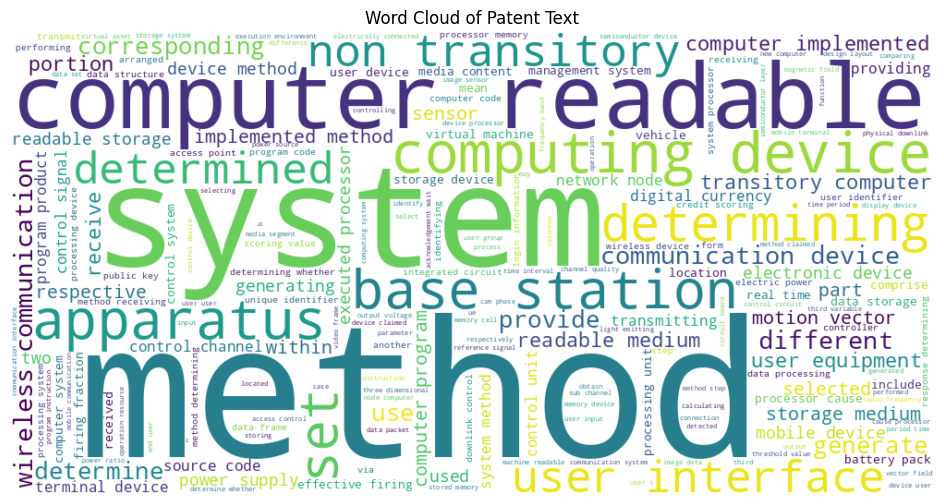

In [50]:
text = " ".join(df_balanced["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of Patent Text")

plt.show()

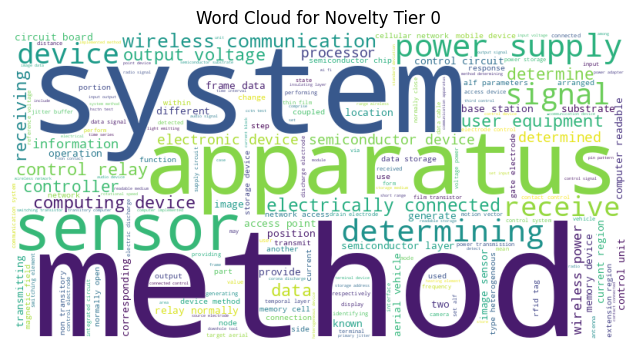

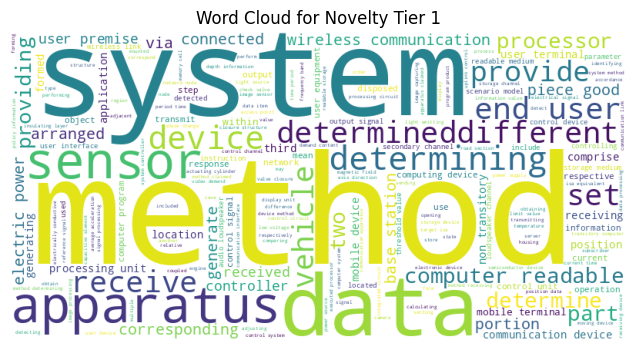

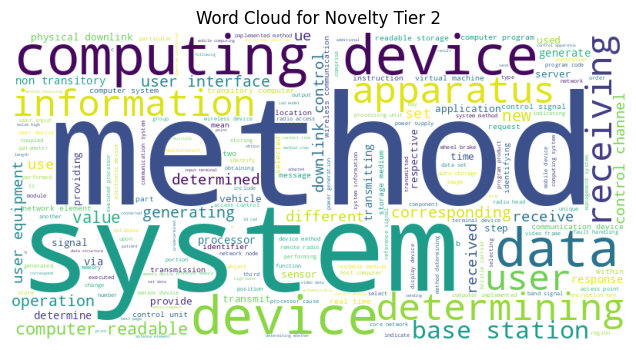

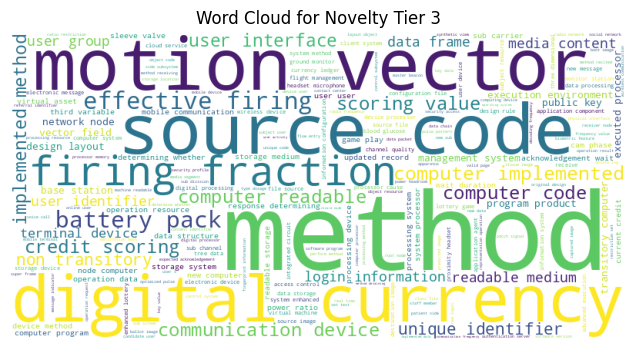

In [51]:
for tier in sorted(df_balanced["novelty tier"].unique()):

    text = " ".join(df_balanced[df_balanced["novelty tier"]==tier]["clean_text"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,4))
    plt.imshow(wordcloud)
    plt.axis("off")

    plt.title(f"Word Cloud for Novelty Tier {tier}")

    plt.show()

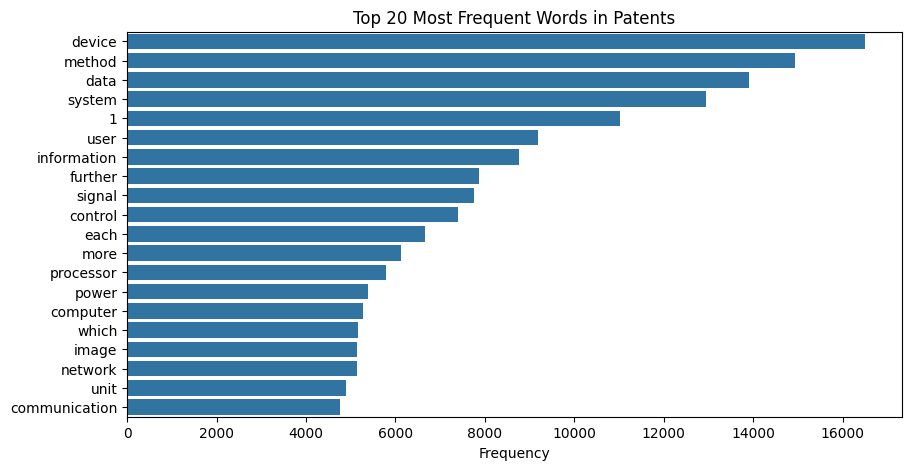

In [52]:
from collections import Counter

words = " ".join(df_balanced["clean_text"]).split()

word_freq = Counter(words).most_common(20)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Frequent Words in Patents")

plt.xlabel("Frequency")

plt.show()

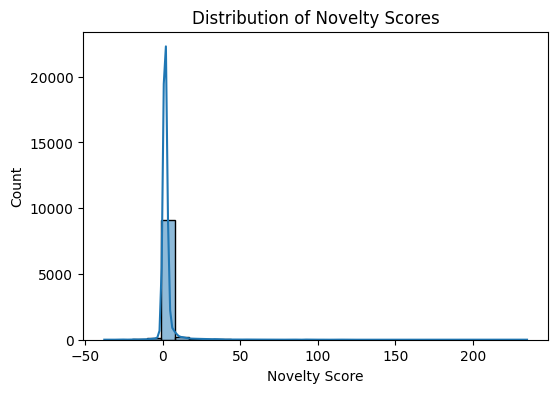

In [53]:
plt.figure(figsize=(6,4))

sns.histplot(df["novelty_score"], bins=30, kde=True)

plt.title("Distribution of Novelty Scores")

plt.xlabel("Novelty Score")

plt.show()

In [54]:
final_dataset = df_balanced[["clean_text","novelty tier"]]

final_dataset.to_csv("final_patent_dataset_balanced.csv", index=False)

print("Final dataset saved")

Final dataset saved


In [55]:
final_dataset.head()

,clean_text,novelty tier
0,cascode semiconductor package related methods ...,1
1,devices systems methods evaluating potential s...,0
2,pressure determination fuel injection valve in...,0
3,multiple transducer method system pipeline ana...,0
4,system method dynamic real time cross selling ...,2


In [56]:
final_dataset.tail()

,clean_text,novelty tier
1595,use buoyancy type power generation method impr...,2
1596,gesture recognition cloud command platform sys...,3
1597,secure digital traffic analysis network monito...,2
1598,electronic system method managing digital cont...,3
1599,method apparatus operating technical system me...,2


## Conclusion

The data engineering pipeline successfully processed raw patent data and transformed it into a structured and analyzable dataset. Through steps such as text preprocessing, stopword removal, novelty scoring, and tier classification, the dataset now highlights meaningful technological patterns.

The resulting dataset can be used for further machine learning tasks such as patent classification, innovation analysis, and trend discovery in hardware technologies.